# Customer Profiling and Visualizations

## Table of Contents
#### 1. Importing Data
#### 2. Global Univariate Analysis - Frequency counts and distributions for:
###### 2.1. Age
###### 2.2. Income
###### 2.3. Number of dependents
###### 2.4. Family status
###### 2.5. Region
###### 2.6. Loyalty flag
#### 3. Transformations needed for the analysis
###### 3.1. Categorization to price-range bins (Low-range, Mid-range, High-range product)
###### 3.2. Sampling data
#### 4. Time-based Volume and Spending Analysis
###### 4.1. Crossing day and hour with order counts
###### 4.2. Crossing day and hour with prices
#### 5. Product Popularity and Ordering Habits Analysis
###### 5.1. Popularity of products and departments
###### 5.2. Ordering habits based on customer's loyalty
###### 5.3. Ordering habits based on customer's region
#### 6. Customer Profiling (Multivariate Intersections)
###### 6.1. Connection between age and family status in terms of ordering habits
###### 6.2. Creating customer profiles
###### 6.3. Ordering habits per customer profile

## 1. Importing libraries and data

In [1]:
# Importing libraries

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [2]:
# Creating main path

path = r'/Users/helenarobalinho/Desktop/Data Analytics/2. Data Immersion/Achievement 4 - Python Fundamentals for Data Analysts/03-2026 Instacart Basket Analysis'

In [3]:
# Importing the final transformed data for section 4.10.1

df_final = pd.read_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'df_final.pkl'))

In [4]:
# Checking the shape

df_final.shape

(30964564, 38)

In [5]:
# Quick check

df_final.head()

,product_id,product_name,aisle_id,department_id,prices,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,...,date_joined,n_dependents,fam_status,income,department,region,customer_activity,age_category,income_category,customer_profile
0,1,Chocolate Sandwich Cookies,61,19,5.8,3139998,138,28,6,11,...,8/1/2019,1,married,49620,snacks,Midwest,High,Older adult,Average income,Older caregivers
1,1,Chocolate Sandwich Cookies,61,19,5.8,1977647,138,30,6,17,...,8/1/2019,1,married,49620,snacks,Midwest,High,Older adult,Average income,Older caregivers
2,1,Chocolate Sandwich Cookies,61,19,5.8,389851,709,2,0,21,...,6/16/2018,2,married,158302,snacks,Northeast,High,Older adult,High income,Older caregivers
5,1,Chocolate Sandwich Cookies,61,19,5.8,1701441,777,16,1,7,...,1/4/2019,2,married,57797,snacks,West,High,Middle-aged adult,Average income,Established family
6,1,Chocolate Sandwich Cookies,61,19,5.8,1871483,825,3,2,14,...,5/8/2019,3,living with parents and siblings,34171,snacks,South,High,Young adult,Average income,Young adult living with parents


## 2. Global Univariate Analysis - Frequency counts and distributions for:

Business Questions Answered:
- What different classifications does the demographic information suggest? (Age? Income? Family status?)
- What is the distribution among users in regards to their brand loyalty?

### 2.1. Age

In [6]:
# Checking statistics for age column

df_final['age'].describe()

count    3.096456e+07
mean     4.946803e+01
std      1.848528e+01
min      1.800000e+01
25%      3.300000e+01
50%      4.900000e+01
75%      6.500000e+01
max      8.100000e+01
Name: age, dtype: float64

- Average age is 49
- Min age is 18
- 25% of people are under 33 years old
- 50% of people are under 49
- 75% of people are under 65
- Max age is 81

- Age groups: 
    - age <= 33 → young adult
    - age > 33 and < 65 → middle-aged adult
    - age > 65 → older adult

In [7]:
# Grouping ages into categories based on the quartiles:

# Classifying 'young adults'
df_final.loc[df_final['age'] <= 33, 'age_category'] = 'Young adult'

# Classifying 'middle-aged adults'
df_final.loc[(df_final['age'] > 33) & ( df_final ['age'] < 65), 'age_category'] = 'Middle-aged adult'

# Classifying 'older adults'
df_final.loc[df_final['age'] >= 65, 'age_category'] = 'Older adult'

In [8]:
# Checking age categories

df_final['age_category'].value_counts(dropna = False)

age_category
Middle-aged adult    15011555
Older adult           8195544
Young adult           7757465
Name: count, dtype: int64

Customer base is mostly made of middle-aged adults (those aged between 33-65), folllowed by older adults, then young adults.

Text(0.5, 1.0, 'Customer age distribution')

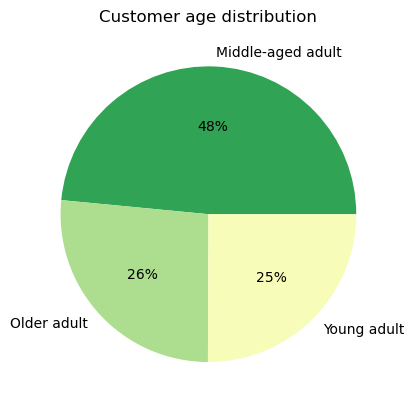

In [9]:
# Creating a pie chart with the 3 age categories

colors = ['#31a354', '#addd8e', '#f7fcb9']  # green, light green, yellow
pie_age = df_final['age_category'].value_counts().plot.pie(autopct='%1.0f%%', colors = colors)
plt.ylabel('') # Remove y-label
plt.title('Customer age distribution') # Add title

Most customers are middle-aged adults (aged 34+). Older (aged 65+) and Young (age < 33) adults make up the other half of the base.

### 2.2. Income

In [10]:
# Checking statistics for age column

df_final['income'].describe()

count    3.096456e+07
mean     9.967587e+04
std      4.314187e+04
min      2.590300e+04
25%      6.729200e+04
50%      9.676500e+04
75%      1.281020e+05
max      5.939010e+05
Name: income, dtype: float64

- Average income is 99,675 USD
- Min income is 25,903 USD
- 25% of people have an income under 67,292 USD
- 50% of people have an income under 96,765 USD
- 75% of people have an income under 128,102 USD
- Max income is  593,901 USD

- Income groups: 
    - income <= 30,000 → low income
    - income > 30,000 and < 100,000 → average income
    - income > 100,000 → high income

In [11]:
# Grouping incomes into categories based on the quartiles:

# Classifying 'low income'
df_final.loc[df_final['income'] <= 30000, 'income_category'] = 'Low income'

# Classifying 'average income'
df_final.loc[(df_final['income'] > 30000) & ( df_final ['income'] < 100000), 'income_category'] = 'Average income'

# Classifying 'high income'
df_final.loc[df_final['income'] >= 100000, 'income_category'] = 'High income'

In [12]:
# Checking income categories

df_final['income_category'].value_counts(dropna = False)

income_category
Average income    16563030
High income       14207402
Low income          194132
Name: count, dtype: int64

Text(0.5, 1.0, 'Customer income distribution')

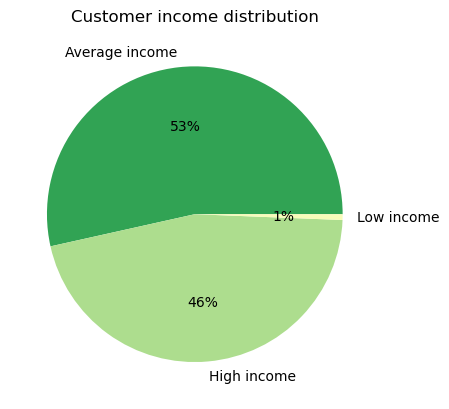

In [13]:
# Creating a pie chart with the 3 income categories

pie_income = df_final['income_category'].value_counts().plot.pie(autopct='%1.0f%%', colors = colors)
colors = ['#31a354', '#addd8e', '#f7fcb9']  # green, light green, yellow
plt.ylabel('') # Remove y-label
plt.title('Customer income distribution') # Add title

- Most customers (53%) earn an average salary (between 30,000 - 100,000), closely followed by high income earners (99,000+) which account for 46%.

- Few customers earn <30,000 and account for only 1% of the customer base.

### 2.3. Number of dependents

In [14]:
# Checking statistics for 'n_dependents' column

df_final['n_dependents'].describe()

count    3.096456e+07
mean     1.501819e+00
std      1.118896e+00
min      0.000000e+00
25%      1.000000e+00
50%      2.000000e+00
75%      3.000000e+00
max      3.000000e+00
Name: n_dependents, dtype: float64

- Average nr of dependents is 1.5
- Min nr of dependents is 0
- Max nr of dependents is 3

In [15]:
# Checking frequency of n_dependents

df_final['n_dependents'].value_counts(dropna = False)

n_dependents
3    7772516
0    7739681
2    7733261
1    7719106
Name: count, dtype: int64

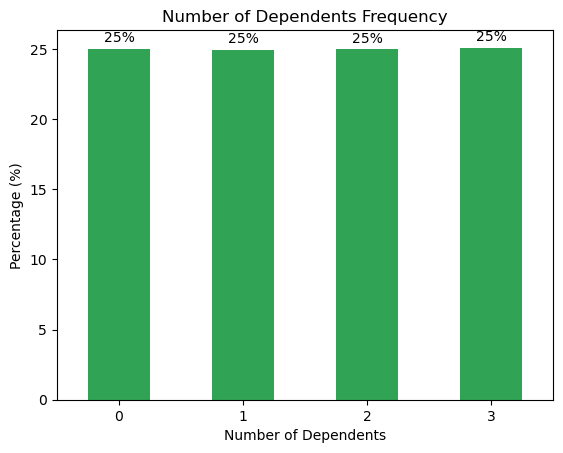

In [16]:
# Creating a bar chart with the n_dependents frequency

freq_dependents = df_final['n_dependents'].value_counts(normalize=True).sort_index() * 100 # Frequencies in %

# Creating the bar chart
bar_dependents = freq_dependents.plot.bar(color='#31a354')
plt.xticks(rotation=0)  # keep x-values in horizontal
plt.title('Number of Dependents Frequency')  # title
plt.ylabel('Percentage (%)')  # y-label
plt.xlabel('Number of Dependents')  # x-label

for i, value in enumerate(freq_dependents):
    bar_dependents.text(i, value + 0.5, f'{value:.0f}%', ha='center') # add bar values

The distribution of dependents is practically uniform between 0 and 3. Each category represents approximately 25% of the population.

### 2.4. Family status

In [17]:
# Checking frequency of fam_status

df_final['fam_status'].value_counts(dropna = False)

fam_status
married                             21743711
single                               5094410
divorced/widowed                     2645271
living with parents and siblings     1481172
Name: count, dtype: int64

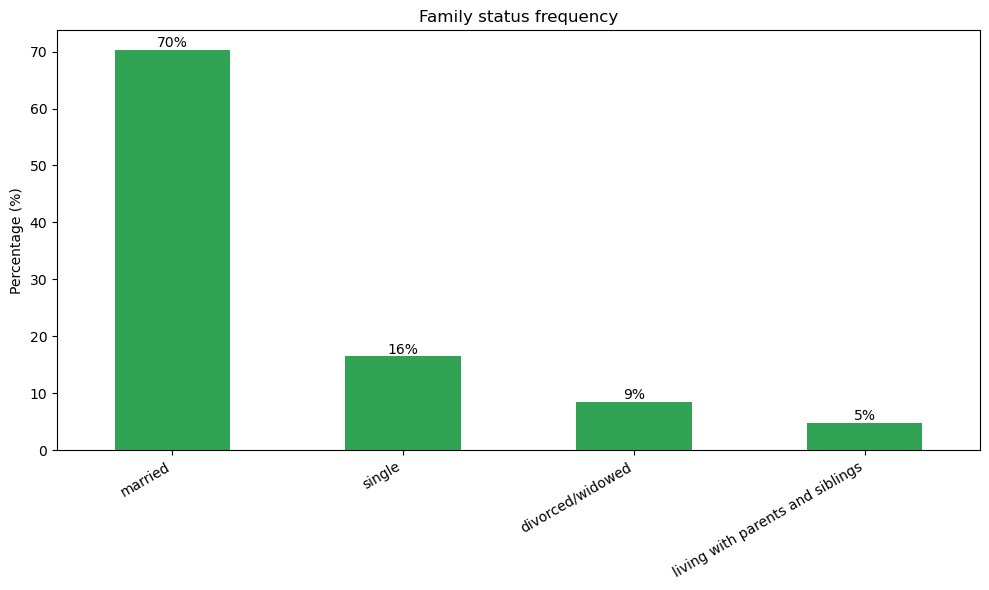

In [77]:
# Creating a bar chart with the fam_status frequency

# Frequencies in %
freq_fam = df_final['fam_status'].value_counts(normalize=True).sort_values(ascending=False) * 100

# Set figure size to give space for labels
plt.figure(figsize=(10,6))

# Creating bar chart
bar_fam_status = freq_fam.plot.bar(color='#31a354')

# Rotate x-axis labels and align them
plt.xticks(rotation=30, ha='right')

# Add titles and labels
plt.title('Family status frequency')
plt.ylabel('Percentage (%)')
plt.xlabel('')

# Add percentage values on top of bars
for i, value in enumerate(freq_fam):
    plt.text(i, value + 0.5, f'{value:.0f}%', ha='center')

# Adjust layout so nothing is cut off
plt.tight_layout()

# Save as PNG
plt.savefig('fam_status_frequency.png', dpi=300)

# Show plot
plt.show()

The majority of customers are married (70%), with much smaller segments of single (16%), divorced/widowed (9%), and those living with parents or siblings (5%).

### 2.5. Region

In [19]:
# Checking the frequency of each region

df_final['region'].value_counts(dropna = False)

region
South        10311139
West          7927227
Midwest       7261513
Northeast     5464685
Name: count, dtype: int64

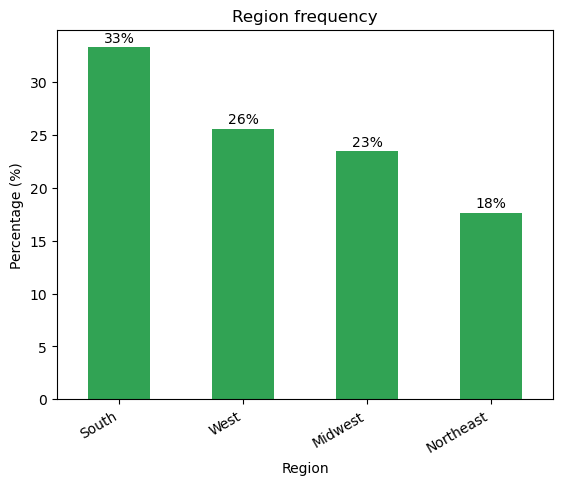

In [20]:
# Creating a bar chart with the region frequency

freq_region = df_final['region'].value_counts(normalize=True).sort_values(ascending=False) * 100 # Frequencies in %
# Creating the bar chart
bar_region = freq_region.plot.bar(color='#31a354')
plt.xticks(rotation=30, ha='right') # rotate x-axis legend
plt.title('Region frequency') # Add title
plt.ylabel('Percentage (%)')  # y-label
plt.xlabel('Region')  # x-label

for i, value in enumerate(freq_region):
    bar_region.text(i, value + 0.5, f'{value:.0f}%', ha='center') # add bar values

Customer distribution is skewed towards the South (33%), with the West and Midwest forming a balanced mid-tier (48% combined), while the Northeast remains the smallest segment (18%).

### 2.6. Loyalty flag

In [21]:
# Checking the frequency of each loyalty_flag

df_final['loyalty_flag'].value_counts(dropna = False)

loyalty_flag
Regular customer    15876776
Loyal customer      10284093
New customer         4803695
Name: count, dtype: int64

Text(0.5, 1.0, 'Customer loyalty distribution')

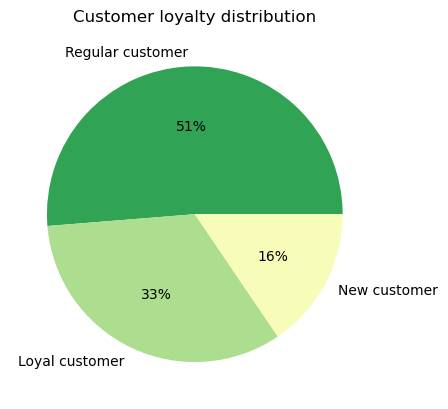

In [22]:
# Creating a pie chart with the 3 loyalty_flag

pie_loyalty_flag = df_final['loyalty_flag'].value_counts().plot.pie(autopct='%1.0f%%', colors = colors)
colors = ['#31a354', '#addd8e', '#f7fcb9']  # green, light green, yellow
plt.ylabel('') # Remove y-label
plt.title('Customer loyalty distribution') # Add title

- Regular customers (51%) form the largest segment, representing the core of the business.
- A substantial share (33%) are loyal customers with high purchase frequency (>40 orders).
- New customers represent only 16%, suggesting either strong retention or slower acquisition.
- Over 80% of customers are repeat buyers (regular + loyal), indicating a strong retention base.

## 3. Transformations needed for the analysis

Business Questions Answered:
- How to use simpler price range groupings to help direct marketing efforts?

### 3.1. Categorization to price-range bins (Low-range, Mid-range, High-range product)

In previous analysis we saw that for a threshold of prices greater than 100, there were 5,127 rows with outlier observations that were skewing the chart.
In order to solve that, those outliers were turned into missing values.

In [23]:
# Turning outliers into NaNs:

df_final.loc[df_final['prices'] > 100, 'prices'] = np.nan

Text(0.5, 0, 'Price (USD)')

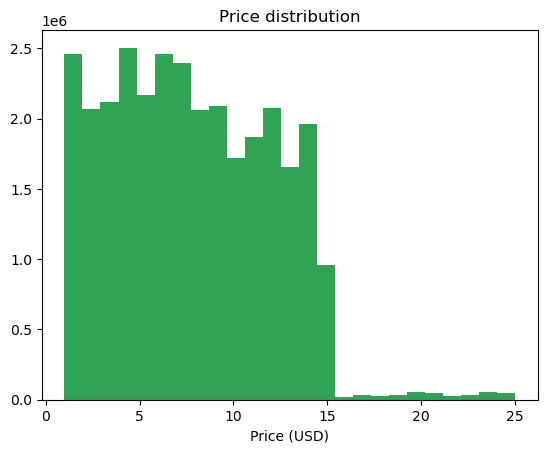

In [24]:
# Creating a histogram of the 'prices column':

hist_prices = df_final['prices'].plot.hist(bins = 25, color = '#31a354')
plt.title('Price distribution') # Add title
plt.ylabel('') # Remove y-label
plt.xlabel('Price (USD)') # x-label

- The histogram shows the price range (1 - 25 USD) and the count of items for each price. 
- Most products are less than 15 USD (low to mid-range).

Prices were previously categorized in the 'price_range_loc' column as:
- If price <=5 → 'Low-range Product'
- If price >5 and <=15 → "Mid-range product"
- If price >15 →'High-range product'

In [25]:
# Checking the frequency of each price category

df_final['price_range_loc'].value_counts(dropna = False)

price_range_loc
Mid-range product     20891771
Low-range product      9674840
High-range product      397953
Name: count, dtype: int64

Text(0.5, 1.0, 'Price categories distribution')

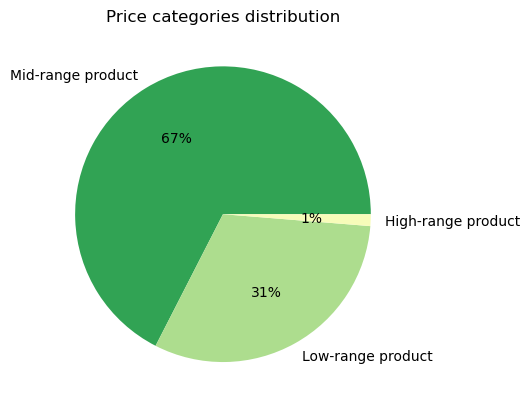

In [26]:
# Creating a pie chart with the 3 price categories

pie_price_range = df_final['price_range_loc'].value_counts().plot.pie(autopct='%1.0f%%', colors = colors)
colors = ['#31a354', '#addd8e', '#f7fcb9']  # green, light green, yellow
plt.ylabel('') # Remove y-label
plt.title('Price categories distribution') # Add title

- Over 67% of the products sold fall into the mid-range category (5-15 USD).
- 31% of the products sold are considered low-range (<5 USD). 
- Very few products (1%) are considered high-range (>15 USD).

- This suggests that there is low demand for premium goods, as most customers buy items in the low to mid-range category.

### 3.2. Sampling data

To start a multivariate analysis, I will use a sample of the data to avoid memory errors. To be accurate, I will split the data into 2 samples with the same distribution 70/30.

In [27]:
# Setting the seed for reproductibility

np.random.seed (4)

In [28]:
# Creating a list holding True/False values to the test np.random.rand() <= 0.7

dev = np.random.rand(len(df_final)) <= 0.7

In [29]:
# Storing 70% of the sample in the df big

big = df_final[dev]

In [30]:
# Storing 30% of the sample in the df small

small = df_final[~dev]

In [31]:
# Check if big is 70% of final_merged and small is 30% of final_merged

len (big) + len (small)

30964564

In [32]:
# Length of the total df is the same

len(df_final)

30964564

In [33]:
# Creating a new df 'final_sample' that contains only our small subset

final_sample = small.copy()

## 4. Time-based Volume and Spending Analysis

Business Questions Answered:

- What are the busiest days of the week and hours of the day?
- Are there particular times of the day when people spend the most money?

### 4.1. Crossing day and hour with order counts

([<matplotlib.axis.XTick at 0x41918e710>,
 [Text(0, 0, 'Sat'),
  Text(1, 0, 'Sun'),
  Text(2, 0, 'Mon'),
  Text(3, 0, 'Tue'),
  Text(4, 0, 'Wed'),
  Text(5, 0, 'Thu'),
  Text(6, 0, 'Fri')])

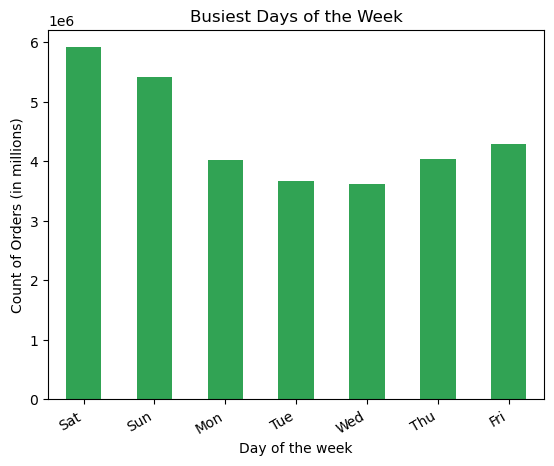

In [34]:
# Creating a bar chart for the "orders_day_of_week" column

bar_orders_day = df_final['orders_day_of_week'].value_counts().sort_index().plot.bar(color='#31a354')
plt.title('Busiest Days of the Week') # title
plt.ylabel('Count of Orders (in millions)') # y-label
plt.xlabel('Day of the week') # x-label
day_labels = ['Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri'] # label day of the week
plt.xticks(ticks=range(7), labels=day_labels, rotation=30, ha='right') # x-label rotation

In [35]:
df_final['orders_day_of_week'].value_counts()

orders_day_of_week
0    5908610
1    5411686
6    4291304
5    4033729
2    4024706
3    3669535
4    3624994
Name: count, dtype: int64

- Based on the count of orders, the busiets days of the week are Saturday and Sunday. 
- Midweek (Tuesday and Wednesday) are the two days with the fewest orders.
- This indicates that ads should be scheduled during midweek to boost orders.

Text(0.5, 0, 'Hour of the day')

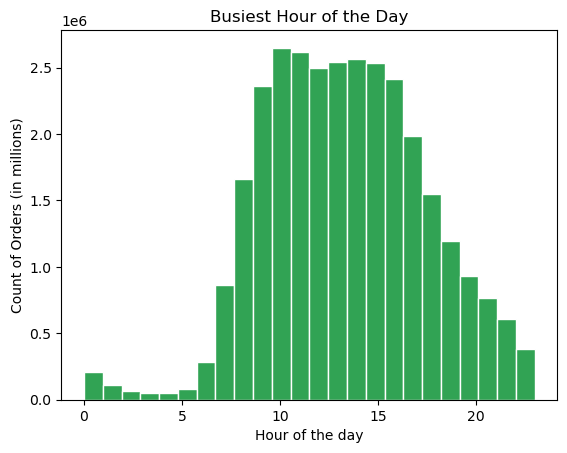

In [36]:
# Creating a histogram of the 'order_hour_of_day' column:

hist_order_hour = df_final['order_hour_of_day'].plot.hist(bins = 24, color='#31a354', edgecolor = 'white')
plt.title('Busiest Hour of the Day') # title
plt.ylabel('Count of Orders (in millions)') # y-label
plt.xlabel('Hour of the day') # x-label

In [37]:
df_final['order_hour_of_day'].value_counts()

order_hour_of_day
10    2649744
11    2614880
14    2567903
13    2539276
15    2535966
12    2495795
16    2413681
9     2363611
17    1982345
8     1659110
18    1551184
19    1193878
20     930909
7      863213
21     763111
22     607060
23     384554
6      281013
0      208042
1      109621
5       84418
2       65691
4       50763
3       48796
Name: count, dtype: int64

- After 5am orders begin to increase, hitting their peak at 10am.
- The busiest hours with the most orders are from 9am-4pm.
- Orders begin to decrease for the day after 3pm and continue to do so until 5am, which are the slowest hours of the business.

### 4.2. Crossing day and hour with prices

([<matplotlib.axis.XTick at 0x4022f0410>,
 [Text(0, 0, 'Sat'),
  Text(1, 0, 'Sun'),
  Text(2, 0, 'Mon'),
  Text(3, 0, 'Tue'),
  Text(4, 0, 'Wed'),
  Text(5, 0, 'Thu'),
  Text(6, 0, 'Fri')])

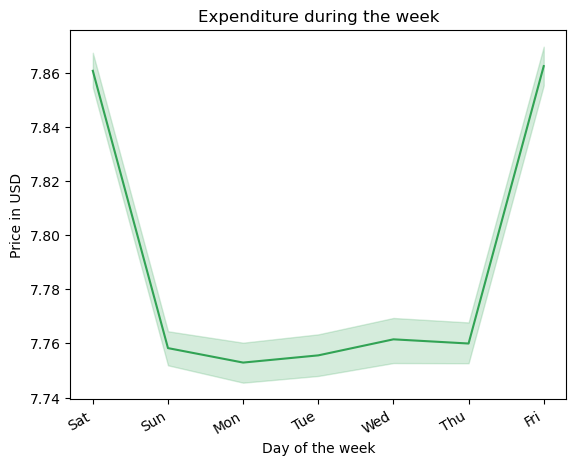

In [38]:
# Creating the line chart day_of_the week vs prices by using the created sample

line_day_prices = sns.lineplot(data = final_sample, x = 'orders_day_of_week', y = 'prices', color='#31a354')
plt.title('Expenditure during the week') # title
plt.ylabel('Price in USD') # y-label
plt.xlabel('Day of the week') # x-label
day_labels = ['Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri'] # label day of the week
plt.xticks(ticks=range(7), labels=day_labels, rotation=30, ha='right') # x-label rotation

- Customer expenditure is the highest on Friday and Saturday and lowest during the rest of the week.
- This suggests customers like to place orders on the weekend to stock up on groceries before the start of the workweek. 

Text(0.5, 0, 'Hour of the day')

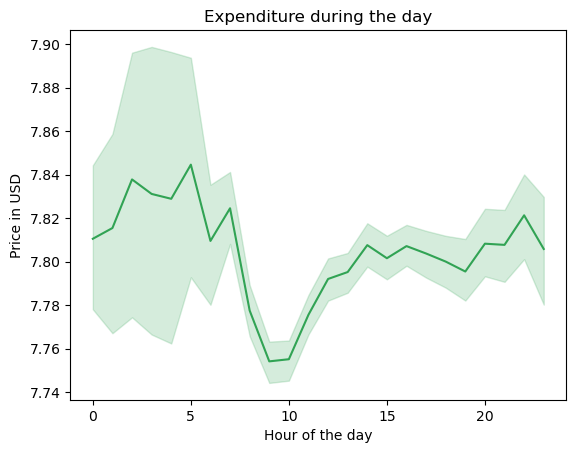

In [39]:
# Creating the line chart day_of_the week vs prices by using the created sample

line_day_prices = sns.lineplot(data = final_sample, x = 'order_hour_of_day', y = 'prices', color='#31a354')
plt.title('Expenditure during the day') # title
plt.ylabel('Price in USD') # y-label
plt.xlabel('Hour of the day') # x-label

- Expenditure is at its highest when order placement is at its lowest (before 5am) and vice versa. This indicates that, although order volume is low during this period, customers tend to purchase higher-priced items more frequently than at other times of the day.

- Price variability is lower during peak hours (9am–evening), indicating more consistent purchasing patterns, while early morning hours show greater variability in prices, likely due to fewer and more heterogeneous orders.

## 5. Product Popularity and Ordering Habits Analysis

Most popular items, how much customers order and how often they order.

Business Questions Answered:

- Are there certain types of products that are more popular than others? Which departments have the highest frequency of product orders?
- Are there differences in ordering habits based on a customer’s loyalty status?
- Are there differences in ordering habits based on a customer’s region?

### 5.1. Popularity of products and departments

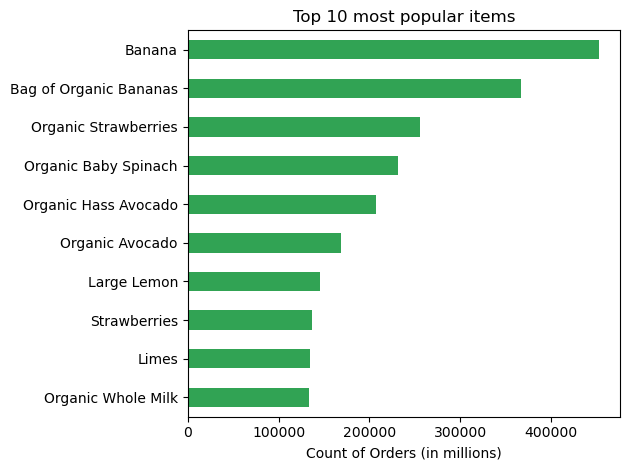

In [78]:
# Creating a bar chart for the "product_name" column

# Plot
bar_products = df_final['product_name'].value_counts().nlargest(10).plot.barh(color='#31a354')
# Invert y-axis
bar_products.invert_yaxis()
plt.title('Top 10 most popular items') # title
plt.xlabel('Count of Orders (in millions)') # x-label
plt.ylabel('') # remove y-label

# Adjust layout so nothing is cut off
plt.tight_layout()

# Save as PNG
plt.savefig('bar_products.png', dpi=300)

# Show plot
plt.show()

- The most popular items are bananas, organic strawberries, organic baby spinach and organic avocados.

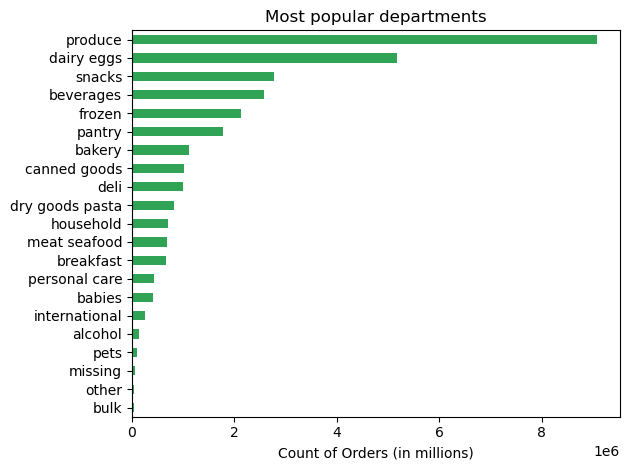

In [79]:
# Creating a bar chart for the "department" column

# Plot
bar_departments = df_final['department'].value_counts().plot.barh(color='#31a354')
# Invert y-axis
bar_departments.invert_yaxis()
plt.title('Most popular departments') # title
plt.xlabel('Count of Orders (in millions)') # x-label
plt.ylabel('') # remove y-label

# Adjust layout so nothing is cut off
plt.tight_layout()

# Save as PNG
plt.savefig('bar_departments.png', dpi=300)

# Show plot
plt.show()

- The top departments with the most orders are produce and dairy/eggs. Followed by snacks, beverages and frozen.
- The departments with the least amount of orders are pets, alcohol, and international.

In [42]:
# Top 10 products

df_final['product_name'].value_counts().nlargest(10)

product_name
Banana                    453164
Bag of Organic Bananas    366403
Organic Strawberries      255988
Organic Baby Spinach      231772
Organic Hass Avocado      206799
Organic Avocado           168267
Large Lemon               145397
Strawberries              136330
Limes                     134751
Organic Whole Milk        133514
Name: count, dtype: int64

In [43]:
# All produce products

produce_products = df_final[df_final['department'] == 'produce']

In [44]:
# Top 10 products from produce department

top10_produce = produce_products['product_name'].value_counts().nlargest(10)

In [45]:
# Checking the output

top10_produce

product_name
Banana                    453164
Bag of Organic Bananas    366403
Organic Strawberries      255988
Organic Baby Spinach      231772
Organic Hass Avocado      206799
Organic Avocado           168267
Large Lemon               145397
Strawberries              136330
Limes                     134751
Organic Raspberries       132945
Name: count, dtype: int64

- 9 out of the 10 most popular products are from the Produce department (+ organic whole milk from dairy/eggs).
- Inside the department Produce we have all the top 9 overall products + organic raspberries.
- The "Fresh Fruits & Vegetables" category completely dominates purchasing behavior.

### 5.2. Ordering habits based on customer's loyalty

In [46]:
# Grouping loyalty_flag to summarize the mean of number of orders and the number of days between orders

loyalty_analysis = df_final.groupby('loyalty_flag').agg({
    'order_number': 'mean',
    'days_since_prior_order': 'mean'
})

In [47]:
loyalty_analysis

,order_number,days_since_prior_order
loyalty_flag,,
Loyal customer,32.641196,6.026656
New customer,4.268295,17.598691
Regular customer,12.347452,12.155135


Text(0.5, 1.0, 'Customer Loyalty: Order Frequency vs Days Between Orders')

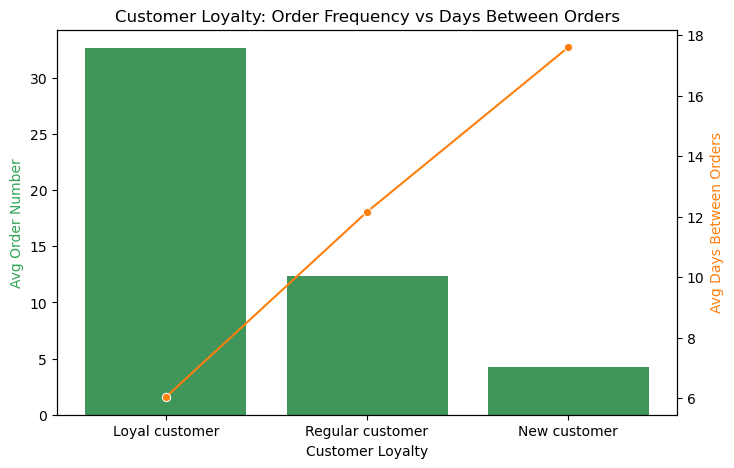

In [48]:
# Combined chart for order frequency and days between orders

# ordering by descendent order
loyalty_analysis = loyalty_analysis.sort_values(by='order_number', ascending=False)
# bar chart for order_number
fig, ax1 = plt.subplots(figsize=(8,5))
bar_loyalty_freq_days = sns.barplot(data=loyalty_analysis, x='loyalty_flag', y='order_number', color='#31a354', ax=ax1)
ax1.set_ylabel('Avg Order Number', color='#31a354')
ax1.set_xlabel('Customer Loyalty')
# secondary axis for days_between_orders
ax2 = ax1.twinx()
sns.lineplot(data=loyalty_analysis, x='loyalty_flag', y='days_since_prior_order', marker='o', color='#ff7f0e', ax=ax2)
ax2.set_ylabel('Avg Days Between Orders', color='#ff7f0e')
#title
plt.title('Customer Loyalty: Order Frequency vs Days Between Orders')

- Loyal customers (those who placed 40+ orders):
    * Order very frequently (on average 32 orders in total)
    * Have short gaps between purchases (6 days)
      
- New customers (those who placed 10 or less orders):
    * Order rarely (on average 4 orders)
    * Have long delays between orders (17 days)
      
- Regular customers sit in between

- Customer loyalty is strongly associated with purchasing behavior. Loyal customers place significantly more orders and 
exhibit shorter intervals between purchases, indicating high engagement. In contrast, new customers show low order frequency and long gaps between purchases, suggesting weaker engagement and retention.

### 5.3. Ordering habits based on customer's region

In [49]:
# Grouping region to summarize the mean of number of orders and the number of days between orders

df_final.groupby('region').agg({
    'order_number': 'mean',
    'days_since_prior_order': 'mean'
})

,order_number,days_since_prior_order
region,,
Midwest,17.602828,10.892736
Northeast,17.921760,10.774220
South,17.844674,10.814227
West,17.971929,10.754622


- Order frequency is between 17 and 18 across all regions. 
- Days between orders is between 10 and 11 across all regions.

- Customer habits are homogeneous across regions and geography does not significantly influence behavior.

### Ordering habits by loyalty and region combined

In [50]:
# Combining loyalty_flag and region 

loyalty_region = df_final.groupby(['loyalty_flag', 'region']).agg({
    'order_number': 'mean',
    'days_since_prior_order': 'mean'
}).reset_index()

In [51]:
loyalty_region.value_counts()

loyalty_flag      region     order_number  days_since_prior_order
Loyal customer    Midwest    32.383753     6.063496                  1
                  Northeast  32.560443     6.038116                  1
                  South      32.751674     6.013278                  1
                  West       32.785251     6.003008                  1
New customer      Midwest    4.263319      17.551746                 1
                  Northeast  4.266020      17.591412                 1
                  South      4.269632      17.638789                 1
                  West       4.272716      17.595088                 1
Regular customer  Midwest    12.291482     12.226796                 1
                  Northeast  12.361722     12.149573                 1
                  South      12.359192     12.143621                 1
                  West       12.374203     12.107515                 1
Name: count, dtype: int64

- There is no significant variation in ordering behavior across regions. Both order frequency and time between orders remain consistent regardless of geographic location.
- Customer behavior is driven by loyalty rather than region.

## 6. Customer Profiling (Multivariate Intersections)

Business Questions Answered:

- Is there a connection between age and family status in terms of ordering habits?
- What differences can you find in ordering habits of different customer profiles? (price, frequency, products)

### 6.1. Connection between age and family status in terms of ordering habits

### Ordering habits based on age

#### * Age vs number of orders and number of days between orders

In [52]:
# Grouping age categories to summarize the mean of number of orders and the number of days between orders

age_analysis = df_final.groupby('age_category').agg({
    'order_number': 'mean',
    'days_since_prior_order': 'mean'
})

In [53]:
age_analysis

,order_number,days_since_prior_order
age_category,,
Middle-aged adult,17.904057,10.804089
Older adult,17.784952,10.791788
Young adult,17.750814,10.841878


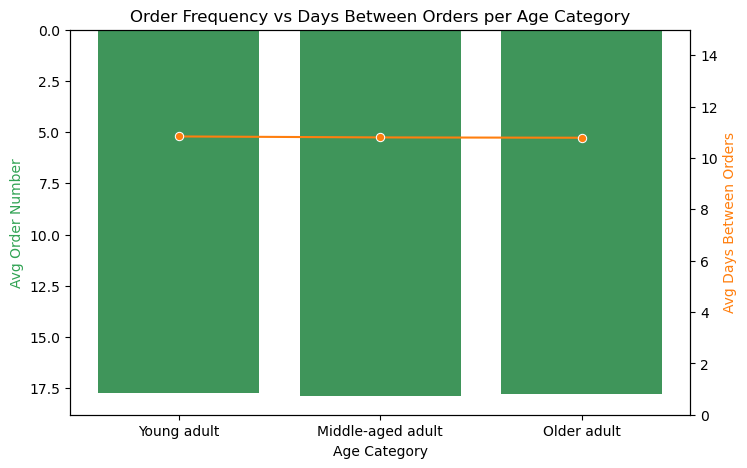

In [54]:
# Combined chart for order frequency and days between orders
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# Aggregate data by age_category
agg_data = df_final.groupby('age_category').agg(avg_order_number=('order_number', 'mean'), avg_days_between=('days_since_prior_order', 'mean')).reset_index()

# Sort by days_between_orders
agg_data = agg_data.sort_values(by='avg_days_between', ascending=False)

# Plot
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar chart for average order number
bar_age_order_freq = sns.barplot(data=agg_data, x='age_category', y='avg_order_number', color='#31a354', ax=ax1)
ax1.set_ylabel('Avg Order Number', color='#31a354')
ax1.set_xlabel('Age Category')
ax1.invert_yaxis()

# Secondary axis for average days between orders
ax2 = ax1.twinx()
line_days_between = sns.lineplot(data=agg_data, x='age_category', y='avg_days_between', marker='o', color='#ff7f0e', ax=ax2)
ax2.set_ylabel('Avg Days Between Orders', color='#ff7f0e')
ax2.set_ylim(0, 15)

plt.title('Order Frequency vs Days Between Orders per Age Category') # Title

# Save the combined plot
combined_path = os.path.join(path, '04 Analysis', 'Visualizations', 'combined_bar_line_age_category.png')
fig.savefig(combined_path, bbox_inches='tight')

- Customer ordering behavior appears highly consistent across age groups.
- The average number of orders and the time between purchases show minimal variation, suggesting that age alone is not a strong driver of purchasing patterns.

#### * Age vs expenditure

In [55]:
# Grouping age categories to summarize the mean of prices

age_analysis_2 = df_final.groupby('age_category').agg({
    'prices': 'mean'})

In [56]:
age_analysis_2

,prices
age_category,
Middle-aged adult,7.790356
Older adult,7.796715
Young adult,7.784572


- This suggests that age alone doesn't play a role in expenditure. Other factors may play a role and will be investigated.

#### * Age vs day of the week

In [57]:
# Checking age and day of the week

crosstab_age_day = pd.crosstab(df_final['orders_day_of_week'], df_final['age_category'], dropna = False)
crosstab_age_day

age_category,Middle-aged adult,Older adult,Young adult
orders_day_of_week,,,
0,2858542,1566244,1483824
1,2622795,1417495,1371396
2,1957328,1065170,1002208
3,1778125,978350,913060
4,1759264,956161,909569
5,1956067,1066115,1011547
6,2079434,1146009,1065861


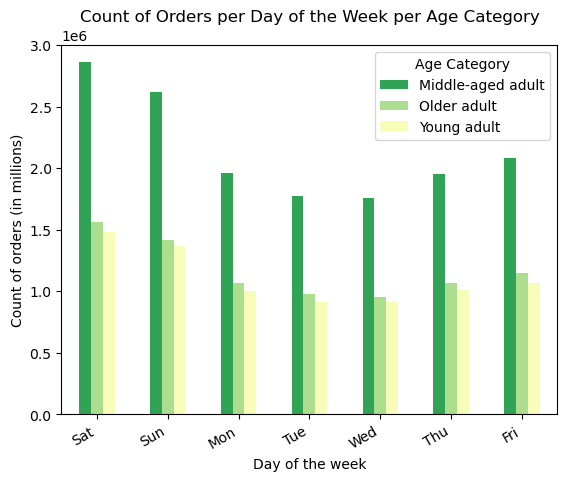

In [58]:
# Graphing crosstab_age_day

bar_age_day = crosstab_age_day.plot(kind = 'bar', color = ['#31a354', '#addd8e', '#f7fcb9'])
plt.title ('Count of Orders per Day of the Week per Age Category') # title
plt.xlabel ('Day of the week') # x-label
plt.ylabel ('Count of orders (in millions)') # y-label
day_labels = ['Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri'] # label day of the week
plt.xticks(ticks=range(7), labels=day_labels, rotation=30, ha='right') # x-label rotation
plt.legend(title='Age Category')

- All age categories place the most orders on Saturday and Sunday.
- This suggests that age does not play a role in ordering habits.

#### * Age vs time of the day

In [59]:
# Checking age and time of day of the orders

crosstab_age_hour = pd.crosstab(df_final['order_hour_of_day'], df_final['age_category'], dropna = False)
crosstab_age_hour

age_category,Middle-aged adult,Older adult,Young adult
order_hour_of_day,,,
0,101028,53395,53619
1,53031,28688,27902
2,31012,17458,17221
3,22857,13395,12544
4,24132,13680,12951
5,40063,23286,21069
6,133272,75229,72512
7,415240,233067,214906
8,805737,441458,411915


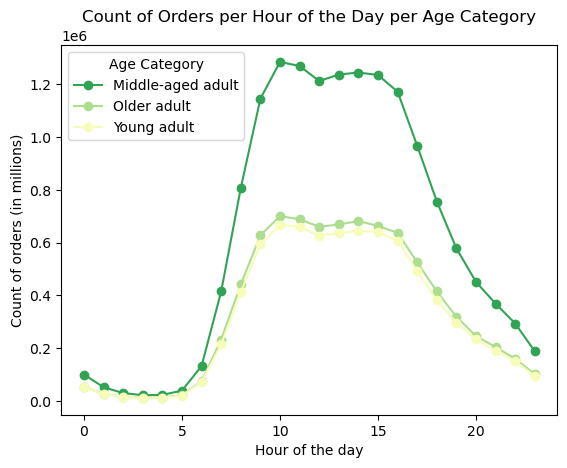

In [60]:
# Graphing crosstab_age_hour

line_age_hour = crosstab_age_hour.plot(kind='line', marker='o', color = ['#31a354', '#addd8e', '#f7fcb9'])
plt.title ('Count of Orders per Hour of the Day per Age Category') # title
plt.xlabel ('Hour of the day') # x-label
plt.ylabel ('Count of orders (in millions)') # y-label
plt.legend(title='Age Category')

- The chart shows that each age group follows the same trend, but in varying degrees.
- Middle-aged adults place the most orders, followed by seniors, with young adults placing the least amount of orders.
- All age groups place the most orders around the same peak 10am-3pm.

### Ordering habits based on family status

In [61]:
# Checking fam_status frequency

df_final['fam_status'].value_counts(dropna=False)

fam_status
married                             21743711
single                               5094410
divorced/widowed                     2645271
living with parents and siblings     1481172
Name: count, dtype: int64

#### * Family status vs number of orders and number of days between orders

In [62]:
# Grouping fam_status to summarize the mean of number of orders and the number of days between orders

fam_status_analysis = df_final.groupby('fam_status').agg({
    'order_number': 'mean',
    'days_since_prior_order': 'mean'
})
fam_status_analysis

,order_number,days_since_prior_order
fam_status,,
divorced/widowed,17.993361,10.750328
living with parents and siblings,18.000712,10.750995
married,17.778735,10.820875
single,17.939521,10.813571


[None, None, None, None]

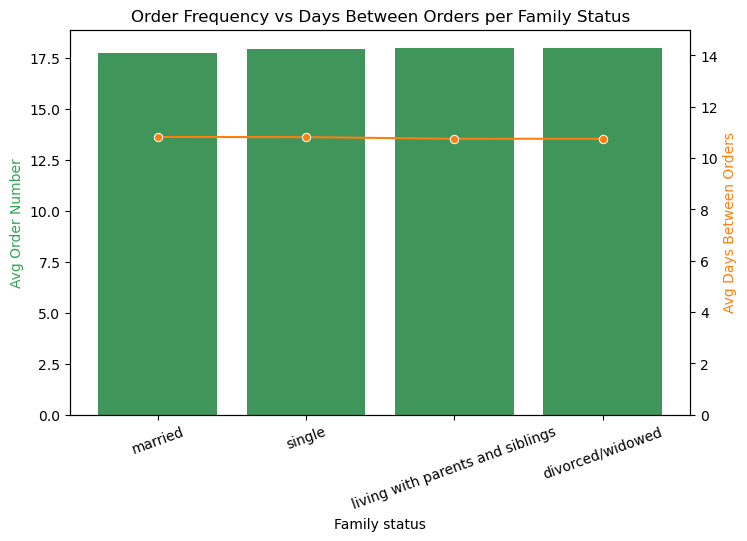

In [63]:
# Combined chart for order frequency and days between orders

# ordering by descendent order
fam_status_analysis = fam_status_analysis.sort_values(by='days_since_prior_order', ascending=False)
# bar chart for order_number
fig, ax1 = plt.subplots(figsize=(8,5))
bar_fam_status_freq = sns.barplot(data=fam_status_analysis, x='fam_status', y='order_number', color='#31a354', ax=ax1)
ax1.set_ylabel('Avg Order Number', color='#31a354')
ax1.set_xlabel('Family status')
# secondary axis for days_between_orders
ax2 = ax1.twinx()
sns.lineplot(data=fam_status_analysis, x='fam_status', y='days_since_prior_order', marker='o', color='#ff7f0e', ax=ax2)
ax2.set_ylabel('Avg Days Between Orders' , color='#ff7f0e')
#title
plt.title('Order Frequency vs Days Between Orders per Family Status')
ax2.set_ylim(0, 15) # forcing y-axis to start in 0
plt.setp(ax1.get_xticklabels(), rotation=20) # x-label rotation

- Married customers tend to order slightly less frequently and wait longer between purchases.
- Although some variation exists across family status groups, the differences are minimal and are not practically significant.   

#### * Family status vs expenditure

In [64]:
# Grouping fam_status to summarize the mean of prices

fam_status_analysis_2 = df_final.groupby('fam_status').agg({
    'prices': 'mean'})
fam_status_analysis_2

,prices
fam_status,
divorced/widowed,7.801014
living with parents and siblings,7.800604
married,7.790278
single,7.783597


- Average prices are very similar (7.78–7.80).
- Those who are divorced/widowed or living with their parents pay a little more.
- Differences are very small, we can conclude that paid price for products doesn't vary much with family status.

#### * Family status vs day of the week

In [65]:
# Checking fam_status and day of the week

crosstab_fam_status_day = pd.crosstab(df_final['orders_day_of_week'], df_final['fam_status'], dropna = False)
crosstab_fam_status_day

fam_status,divorced/widowed,living with parents and siblings,married,single
orders_day_of_week,,,,
0,502506,280828,4150704,974572
1,459198,259482,3789854,903152
2,343839,192366,2829759,658742
3,315320,174418,2578075,601722
4,306704,173214,2546521,598555
5,348434,195460,2824095,665740
6,369270,205404,3024703,691927


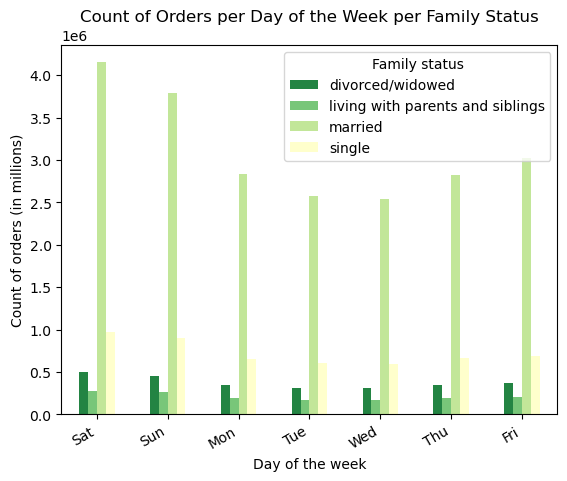

In [66]:
# Graphing crosstab_fam_status_day

bar_fam_status_day = crosstab_fam_status_day.plot(kind = 'bar', color = ['#238443', '#78c679', '#c2e699', '#ffffcc'])
plt.title ('Count of Orders per Day of the Week per Family Status') # title
plt.xlabel ('Day of the week') # x-label
plt.ylabel ('Count of orders (in millions)') # y-label
day_labels = ['Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri'] # label day of the week
plt.xticks(ticks=range(7), labels=day_labels, rotation=30, ha='right') # x-label rotation
plt.legend(title='Family status')

- Married is the most active group.
- Divorced/widowed and living with parents have the less activity.
- Overall behavior is consistent with family shopping patterns: married couples shop more throughout the week.

#### * Family status vs time of the day

In [67]:
# Checking fam_status and time of day of the orders

crosstab_fam_status_hour = pd.crosstab(df_final['order_hour_of_day'], df_final['fam_status'], dropna = False)
crosstab_fam_status_hour

fam_status,divorced/widowed,living with parents and siblings,married,single
order_hour_of_day,,,,
0,16150,10657,145951,35284
1,8582,5556,77334,18149
2,6174,3489,45470,10558
3,4443,2536,33885,7932
4,3997,2794,35764,8208
5,7774,4337,58797,13510
6,23577,14866,195277,47293
7,77304,42229,600913,142767
8,142533,75827,1167336,273414


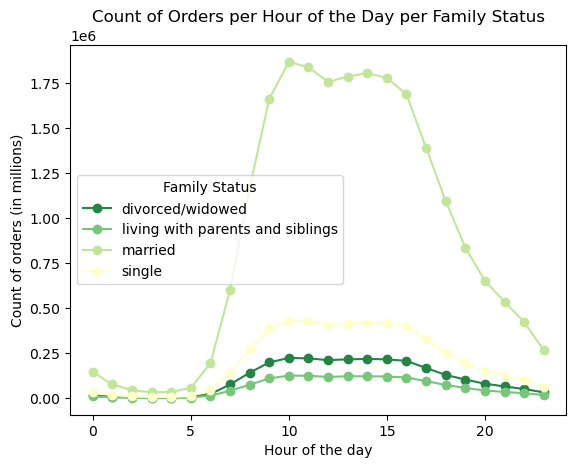

In [68]:
# Graphing crosstab_fam_status_hour

line_fam_status_hour = crosstab_fam_status_hour.plot(kind='line', marker='o', color = ['#238443', '#78c679', '#c2e699', '#ffffcc'])
plt.title ('Count of Orders per Hour of the Day per Family Status') # title
plt.xlabel ('Hour of the day') # x-label
plt.ylabel ('Count of orders (in millions)') # y-label
plt.legend(title='Family Status')

- Peak activity time is the morning and early afternoon.
- Married are the most active customers at all times.
- Smaller groups (living with parents/divorced) have purchases concentrated during peak hours, but in smaller quantities.

Overall:
- Age doesn't greatly affect ordering habits but family status, on the other hand, does seem to influence it. 
- People's ordering habits are similar, but how much they order varies depending on their family status.
- Married people order more, while people living with their parents or divorced people order less.

### Ordering habits based on age and family status combined 

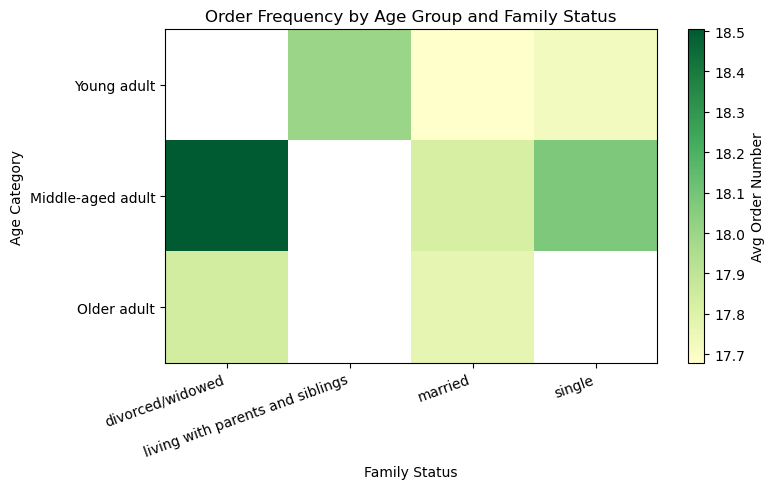

In [76]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Data aggregation
df_grouped = df_final.groupby(['age_category', 'fam_status']).agg({
    'order_number': 'mean',
    'days_since_prior_order': 'mean'
}).reset_index()


# Colors
colors = ['#ffffcc', '#d9f0a3', '#addd8e', '#78c679', '#41ab5d', '#238443', '#005a32']
cmap = LinearSegmentedColormap.from_list('custom_green', colors)

# Pivot table
pivot_heatmap = df_grouped.pivot(index='age_category', columns='fam_status', values='order_number')

# Reorder age groups
age_order = ['Young adult', 'Middle-aged adult', 'Older adult']
pivot_heatmap = pivot_heatmap.reindex(age_order)

# Plotting the heatmap
plt.figure(figsize=(8, 5))
plt.imshow(pivot_heatmap, aspect='auto', cmap=cmap)

# Colorbar
plt.colorbar(label='Avg Order Number')

# Axis labels & ticks
plt.xticks(range(len(pivot_heatmap.columns)), pivot_heatmap.columns, rotation=20, ha='right')
plt.yticks(range(len(pivot_heatmap.index)), pivot_heatmap.index)

plt.title('Order Frequency by Age Group and Family Status')
plt.xlabel('Family Status')
plt.ylabel('Age Category')

plt.tight_layout()
plt.savefig('heatmap_age_family.png', dpi=300, bbox_inches='tight')
plt.show()

### 6.2. Creating customer profiles

Here I will create customer profiles combining age, number of dependents and family status to a much richer segmentation. This gives us a combination of life stage, household type and family obligations.

In [70]:
df_final['age_category'].value_counts()

age_category
Middle-aged adult    15011555
Older adult           8195544
Young adult           7757465
Name: count, dtype: int64

In [71]:
# Creating customer profiles

# Conditions:
conditions = [
    (df_final['age'] <= 33) & (df_final['n_dependents'] == 0) & (df_final['fam_status'] == 'single'), # Young Adult, no dependents, single
    (df_final['age'] <= 33) & (df_final['n_dependents'] >= 1) & (df_final['fam_status'] == 'married'), # Young Adult, 1+ dependents, married
    (df_final['age'] >= 65) & (df_final['n_dependents'] == 0) & (df_final['fam_status'] == 'divorced/widowed'), # Older Adult, no dependents, divorced/widowed
    (df_final['age'] >= 34) & (df_final['age'] < 65) & (df_final['n_dependents'] >= 1) & (df_final['fam_status'] == 'married'), # Middle-Aged Adult, 1+ dependents, married
    (df_final['age'] <= 33) & (df_final['fam_status'] == 'living with parents and siblings'), # Young Adult, living with parents
    (df_final['age'] >= 34) & (df_final['age'] < 65) & (df_final['n_dependents'] == 0) & (df_final['fam_status'] == 'married'), # Middle-Aged Adult, no dependents, married
    (df_final['age'] >= 65) & (df_final['n_dependents'] >= 1) & (df_final['fam_status'] == 'married'), # Older Adult, 1+ dependents, married
    (df_final['age'] >= 34) & (df_final['age'] < 65) & (df_final['n_dependents'] == 0) & ((df_final['fam_status'] == 'single') | (df_final['fam_status'] == 'divorced/widowed')) # Middle-Aged Adult, no dependents, Single or Divorced/Widowed
]

# Corresponding outputs:
profile = [
    'Young professional', # Convenience, individual portions (lives alone and shops late evening)
    'Young family', # Medium volume, baby products (couple with young kids, large weekly shops, family-size products)
    'Independent senior', # Routine, health focus, low  (lives alone, prefers known brands, morning shopper)
    'Established family', # High volume, price-sensitive (Full household, bulk monthly shops, meal planning)
    'Young adult living with parents', # Budget-conscious, mixed needs
    'Empty-nest older couple', # Premium, quality > quantity (kids left home, shops for two)
    'Older caregivers', # Multi-gen products, health, treats (supporting adult children/grandchildren, regular shoppers)
    'Solo settler' # Medium basket size, higher value, regular but not daily (lives alone, higher budget than young singles)
]

In [72]:
# Apply the vectorized logic

df_final['customer_profile'] = np.select(conditions, profile, default='Other')

In [73]:
# Checking the output

df_final.head()

,product_id,product_name,aisle_id,department_id,prices,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,...,date_joined,n_dependents,fam_status,income,department,region,customer_activity,age_category,income_category,customer_profile
0,1,Chocolate Sandwich Cookies,61,19,5.8,3139998,138,28,6,11,...,8/1/2019,1,married,49620,snacks,Midwest,High,Older adult,Average income,Older caregivers
1,1,Chocolate Sandwich Cookies,61,19,5.8,1977647,138,30,6,17,...,8/1/2019,1,married,49620,snacks,Midwest,High,Older adult,Average income,Older caregivers
2,1,Chocolate Sandwich Cookies,61,19,5.8,389851,709,2,0,21,...,6/16/2018,2,married,158302,snacks,Northeast,High,Older adult,High income,Older caregivers
5,1,Chocolate Sandwich Cookies,61,19,5.8,1701441,777,16,1,7,...,1/4/2019,2,married,57797,snacks,West,High,Middle-aged adult,Average income,Established family
6,1,Chocolate Sandwich Cookies,61,19,5.8,1871483,825,3,2,14,...,5/8/2019,3,living with parents and siblings,34171,snacks,South,High,Young adult,Average income,Young adult living with parents


In [74]:
df_final['customer_profile'].value_counts(dropna = False)

customer_profile
Established family                 11233531
Older caregivers                    6173586
Young family                        4336594
Solo settler                        3778024
Independent senior                  2021958
Young professional                  1939699
Young adult living with parents     1481172
Name: count, dtype: int64

In [75]:
df_other = df_final[df_final['customer_profile'] == 'Other']

In [76]:
df_other.shape # all customers fit in one of the 7 created profiles

(0, 38)

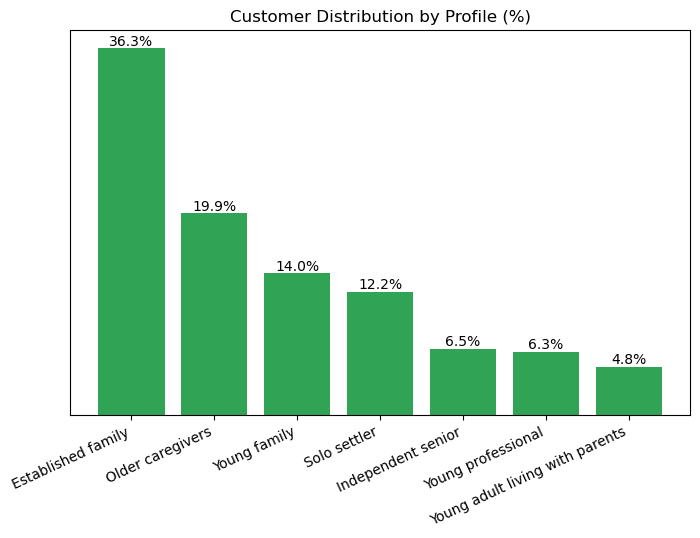

In [116]:
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import os

# Bar chart percentages of customer profiles
percentages_profile = df_final['customer_profile'].value_counts(normalize=True) * 100

# Plot
fig, ax = plt.subplots(figsize=(8,5))
bar_percentages_profile = ax.bar(range(len(percentages_profile)), percentages_profile.values, color='#31a354')

# X-axis labels
ax.set_xticks(range(len(percentages_profile)))
ax.set_xticklabels(percentages_profile.index, rotation=25, ha='right')

# Title and labels
plt.title('Customer Distribution by Profile (%)')
plt.xlabel('')
plt.ylabel('')

# Format Y-axis as percentages
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# Add percentage labels on top of bars
for i, value in enumerate(percentages_profile.values):
    ax.text(
        i,
        value,
        f'{value:.1f}%',
        ha='center',
        va='bottom'
    )

# Remove Y-axis ticks
ax.set_yticks([])

# Save the figure
save_path = os.path.join(path, '04 Analysis', 'Visualizations', 'customer_profile_percentages.png')
fig.savefig(save_path, bbox_inches='tight')

### 6.3. Ordering habits per customer profile

### Ordering habits of different customer profiles - price

In [81]:
# Grouping profiles to summarize the mean of prices

profile_prices_analysis = df_final.groupby('customer_profile').agg({
    'prices': 'mean'})
profile_prices_analysis

,prices
customer_profile,
Established family,7.791088
Independent senior,7.801982
Older caregivers,7.794990
Solo settler,7.788181
Young adult living with parents,7.800604
Young family,7.781473
Young professional,7.779257


- The column 'price' show us the average price per product purchased, not the total cost.
- This doesn't mean they spend the same amount, but isntead all profiles buy products with similar prices.
- Probably profiles differ on quantity per order, type of products and order frequency.

- Customer profiles show very similar average product prices, suggesting that differences in spending behavior are driven more by purchase frequency and basket size rather than product price.

### Ordering habits of different customer profiles - order frequency

In [82]:
# Grouping profiles to summarize the mean of number of orders and the number of days between orders

profile_orders_analysis = df_final.groupby('customer_profile').agg({
    'order_number': 'mean',
    'days_since_prior_order': 'mean'})
profile_orders_analysis

,order_number,days_since_prior_order
customer_profile,,
Established family,17.823031,10.822048
Independent senior,17.835837,10.768514
Older caregivers,17.768287,10.799413
Solo settler,18.144977,10.750703
Young adult living with parents,18.000712,10.750995
Young family,17.678863,10.848389
Young professional,17.720852,10.896793


- Order counts variation is very small across profiles and all profiles shop roughly every 2 weeks.
- Profiles like Solo settler and Young adult living with parents are slightly more recurrent in their ordering habits (maybe they can be targeted with loyalty programs).
- Shopping frequency is driven more by necessity than demographics. 
- Product choice and basket size likely vary more than frequency.

### Ordering habits of different customer profiles - products

In [83]:
# Grouping profiles to summarize the mode of product department

profile_department_analysis = df_final.groupby('customer_profile').agg({
    'department': lambda x: x.mode()[0]  # grabs the first mode
})
profile_department_analysis

,department
customer_profile,
Established family,produce
Independent senior,produce
Older caregivers,produce
Solo settler,produce
Young adult living with parents,produce
Young family,produce
Young professional,produce


In [84]:
# Grouping profiles to summarize the mode of product department

profile_department_analysis = df_final.groupby('customer_profile').agg({
    'product_name': lambda x: x.mode()[0]  # grabs the first mode
})
profile_department_analysis

,product_name
customer_profile,
Established family,Banana
Independent senior,Banana
Older caregivers,Banana
Solo settler,Banana
Young adult living with parents,Banana
Young family,Banana
Young professional,Banana


- Fresh fruits & vegetables and, more specifically, bananas are the favorite products across all customer profiles.

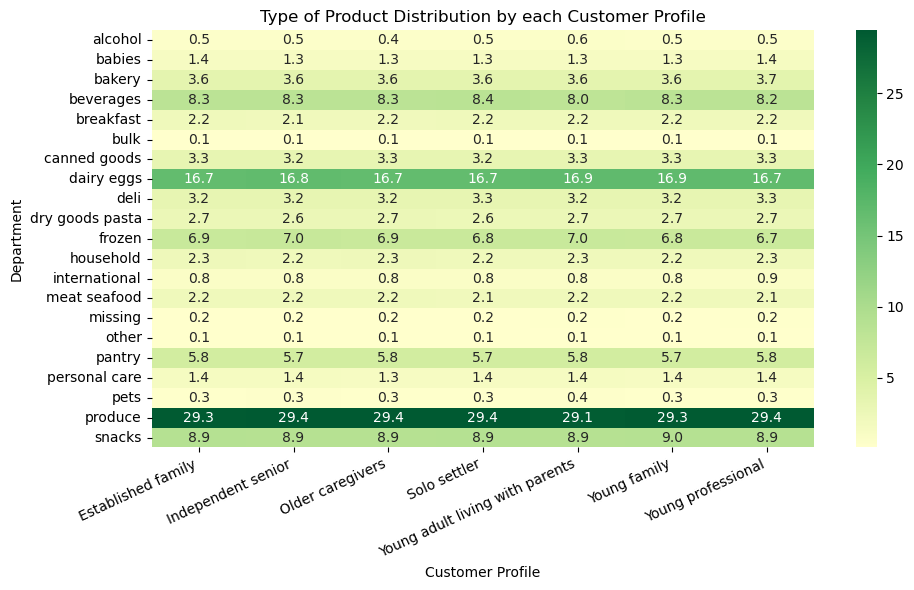

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Crosstab of profile and departments to see if certain items are popular among different customer segments 

crosstab_profile_department = pd.crosstab(df_final['department'], df_final['customer_profile'])

# Normalize to %
crosstab_profile_department = (crosstab_profile_department.div(crosstab_profile_department.sum(axis=0), axis=1) * 100)
    
# Defining colors
colors = ['#ffffcc', '#d9f0a3', '#addd8e', '#78c679', '#41ab5d', '#238443', '#005a32']
cmap = LinearSegmentedColormap.from_list('custom_green', colors)

# Plotting heatmap
plt.figure(figsize=(10, 6))
heatmap_profile_department = sns.heatmap(crosstab_profile_department, cmap=cmap, annot=True, fmt='.1f')  # float (%)

# Labels
plt.title('Type of Product Distribution by each Customer Profile')
plt.ylabel('Department')
plt.xlabel('Customer Profile')
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)                                      
plt.tight_layout()

- This heatmap shows that Produce is universally the top department for all profiles. Dairy & eggs is also consistently important.
- The Young adult living with parents profile is the most distinctive: less produce, less beverages, more frozen foods, more alcohol, more pets. This could reflect shared household dynamics where purchasing decisions are split.
- Despite 7 different life-stage profiles, variation remains minimal.

### Ordering habits of different customer profiles - basket size

Since the average price per product purchased doesn't vary much, we can now analyse the basket size by profile. The average order value will not be analysed, since total order value will mostly correlate with basket size.

In [86]:
# Basket size is the number of products per order_id

basket_size = df_final.groupby('order_id').size().reset_index(name='n_items')
basket_size

,order_id,n_items
0,2,9
1,3,8
2,4,13
3,5,26
4,6,3
...,...,...
3064370,3421079,1
3064371,3421080,9
3064372,3421081,7
3064373,3421082,7


In [87]:
# Adding the customer_profile to each order_id

order_profile = df_final[['order_id', 'customer_profile']].drop_duplicates()
basket_size = basket_size.merge(order_profile, on='order_id', how='left')
basket_size

,order_id,n_items,customer_profile
0,2,9,Established family
1,3,8,Established family
2,4,13,Older caregivers
3,5,26,Established family
4,6,3,Young family
...,...,...,...
3064370,3421079,1,Established family
3064371,3421080,9,Solo settler
3064372,3421081,7,Established family
3064373,3421082,7,Older caregivers


In [88]:
# Grouping the profiles to calculate the mean of basket size

basket_size_profile = basket_size.groupby('customer_profile')['n_items'].mean().reset_index()
basket_size_profile.rename(columns={'n_items': 'avg_basket_size'}, inplace=True) # renaming the column
basket_size_profile

,customer_profile,avg_basket_size
0,Established family,10.112827
1,Independent senior,10.059292
2,Older caregivers,10.059583
3,Solo settler,10.070353
4,Young adult living with parents,10.188489
5,Young family,10.162574
6,Young professional,10.124377


- Basket size is very consistent across all customer profiles, with customers purchasing on average 10 items per order, indicating that differences in purchasing behavior are not driven by order size.

### Ordering habits of different customer profiles - day of the week and time of the day

In [89]:
# Checking profile and day of the week

crosstab_profile_day = pd.crosstab(df_final['orders_day_of_week'], df_final['customer_profile'], normalize='columns') * 100  # show in %
crosstab_profile_day

customer_profile,Established family,Independent senior,Older caregivers,Solo settler,Young adult living with parents,Young family,Young professional
orders_day_of_week,,,,,,,
0,19.002404,19.087390,19.118629,19.160836,18.959851,19.272221,18.932731
1,17.466877,17.228300,17.318071,17.486601,17.518695,17.492092,18.216899
2,13.053474,12.968815,13.006152,12.995206,12.987418,12.923668,12.857407
3,11.861124,12.034770,11.905755,11.797225,11.775675,11.775140,11.754504
4,11.735117,11.618787,11.682578,11.672663,11.694388,11.691641,11.823278
5,12.940241,13.006699,13.009052,13.298513,13.196307,13.082248,12.824825
6,13.940764,14.055238,13.959763,13.588955,13.867667,13.762990,13.590356


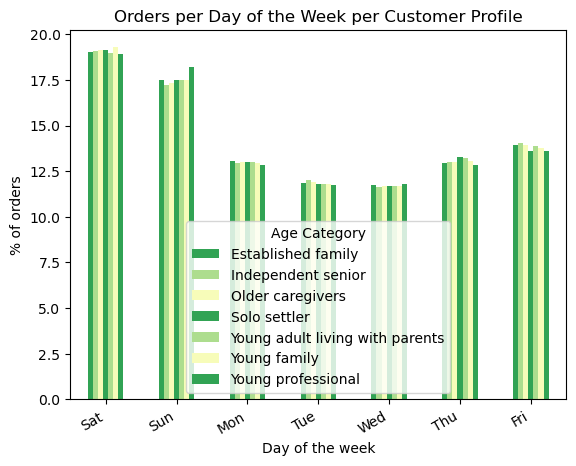

In [90]:
# Graphing crosstab_profile_day

bar_profile_day = crosstab_profile_day.plot(kind = 'bar', color = ['#31a354', '#addd8e', '#f7fcb9'])
plt.title ('Orders per Day of the Week per Customer Profile') # title
plt.xlabel ('Day of the week') # x-label
plt.ylabel ('% of orders') # y-label
day_labels = ['Sat', 'Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri'] # label day of the week
plt.xticks(ticks=range(7), labels=day_labels, rotation=30, ha='right') # x-label rotation
plt.legend(title='Age Category')

- Customer profiles do not meaningfully differ in when they shop during the week.
- This is a strong signal that shopping timing is habit-driven, not profile-driven.
- There is a classic weekly cycle: main shopping moment in the start of the week, low activity during mid-week and a second shopping peak in the weekends. Purchasing timing is driven by weekly routines rather than differences between customer segments.
- There are some small differences like Young professionals that slightly shop more on Sundays and Young families slightly shop more on Saturdays. But these differences are too small to be targeted differently.
- Shopping is synchronized across all customer types and promotions can be timed globally, not per profile: before the weekend.

In [91]:
# Checking profile and hour of the day

crosstab_profile_hour = pd.crosstab(df_final['order_hour_of_day'], df_final['customer_profile'], normalize='columns') * 100  # show in %
crosstab_profile_hour

customer_profile,Established family,Independent senior,Older caregivers,Solo settler,Young adult living with parents,Young family,Young professional
order_hour_of_day,,,,,,,
0,0.665223,0.612129,0.664411,0.696131,0.719498,0.696514,0.657679
1,0.352472,0.321619,0.359354,0.355636,0.375108,0.358669,0.350157
2,0.205643,0.239322,0.204403,0.209395,0.235557,0.224831,0.205290
3,0.152579,0.178688,0.158449,0.151322,0.171216,0.160564,0.156983
4,0.160644,0.149311,0.172687,0.161090,0.188634,0.162731,0.159819
5,0.267921,0.296643,0.280032,0.263789,0.292809,0.263156,0.274269
6,0.888171,0.922670,0.916372,0.886680,1.003665,0.897732,0.964840
7,2.751174,2.920733,2.818637,2.810623,2.851053,2.717524,2.826676
8,5.333871,5.335966,5.403132,5.467276,5.119392,5.409476,5.232822


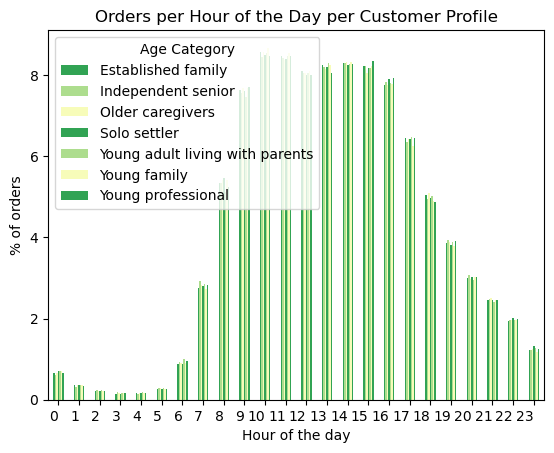

In [92]:
# Graphing crosstab_profile_hour

bar_profile_hour = crosstab_profile_hour.plot(kind = 'bar', color = ['#31a354', '#addd8e', '#f7fcb9'])
plt.title ('Orders per Hour of the Day per Customer Profile') # title
plt.xlabel ('Hour of the day') # x-label
plt.ylabel ('% of orders') # y-label
plt.xticks(rotation=0, ha='right') # x-label rotation
plt.legend(title='Age Category')

- Across all profiles, the pattern is almost identical and there is an universal daily shopping curve.
- Peak shopping window is highly consistent between 10:00 and 15:00 and each hour in this range contributes around 8% of daily orders.
- Differences between profiles are extremely small and no profile shows a distinct “night shopper” or “evening-heavy” pattern.
- This shows that time of the day is not a strong differentiator and behavior is driven by daily routines (work, meals, lifestyle).

### Ordering habits of different customer profiles - Region

While customer ordering behavior (frequency and timing) is consistent across regions, suggesting that geography does not drive how customers shop, regional segmentation may still provide value when analyzing product preferences. Even if behavior is the same, what people buy may differ by region.

In [93]:
# Checking department and region

crosstab_department_region = pd.crosstab(df_final['department'], df_final['region'])
crosstab_department_region

region,Midwest,Northeast,South,West
department,,,,
alcohol,34043,25017,48813,36754
babies,95741,72712,139511,102428
bakery,261753,199300,371620,288155
beverages,598979,462929,859419,650574
breakfast,156155,117904,223172,173619
bulk,7929,5599,11180,8743
canned goods,237459,176936,337458,260221
dairy eggs,1212490,914616,1723016,1327060
deli,234464,178398,333620,257352


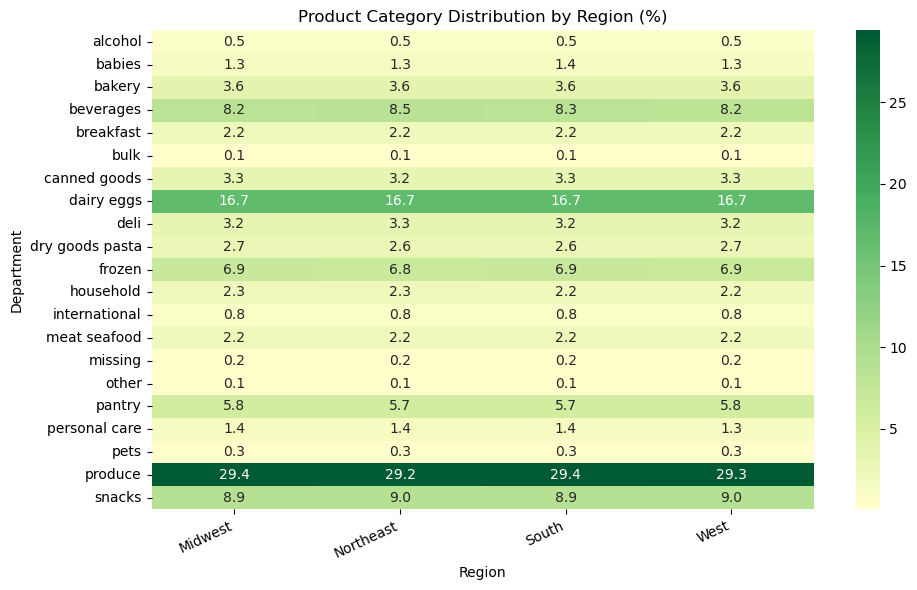

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Normalize by column (region)
crosstab_department_region_pct = crosstab_department_region.div(crosstab_department_region.sum(axis=0), axis=1) * 100 # normalizing for %

# Defining colors
colors = ['#ffffcc', '#d9f0a3', '#addd8e', '#78c679', '#41ab5d', '#238443', '#005a32']
cmap = LinearSegmentedColormap.from_list('custom_green', colors)

# Plotting heatmap
plt.figure(figsize=(10, 6))
heatmap_department_region = sns.heatmap(crosstab_department_region_pct, cmap=cmap, annot=True,fmt='.1f'  # float (%)
)

# Labels
plt.title('Product Category Distribution by Region (%)')
plt.ylabel('Department')
plt.xlabel('Region')
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

- Department popularity is similar across all regions, so core grocery needs are universal regardless of region. No region stands out as meaningfully different.
- Produce  is the most popular department along with dairy/eggs.
- Northeast has the highest beverages share (8.5%) and the lowest produce (29.2%), suggesting a very slight lean toward drinks.
- Core categories such as produce, dairy, and snacks dominate in all regions, but differences in category mix suggest that geography influences what customers buy rather than how they shop. Differences are not in behavior, but in consumption mix.
- This suggests geography is not a driver of purchasing behavior in this dataset, regional marketing differentiation may not be warranted.

## Final data and visualizations exporting

In [95]:
# Checking final columns

df_final.columns

Index(['product_id', 'product_name', 'aisle_id', 'department_id', 'prices',
       'order_id', 'user_id', 'order_number', 'orders_day_of_week',
       'order_hour_of_day', 'days_since_prior_order', 'first_order',
       'add_to_cart_order', 'reordered', '_merge', 'price_range_loc',
       'busiest_day', 'busiest_days', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'avg_product_price', 'spending_flag',
       'median_days_between_orders', 'order_frequency_flag', 'gender', 'state',
       'age', 'date_joined', 'n_dependents', 'fam_status', 'income',
       'department', 'region', 'customer_activity', 'age_category',
       'income_category', 'customer_profile'],
      dtype='object')

In [96]:
# Changing the column name 'First_order' to 'first_order'

df_final.rename(columns={'First_order': 'first_order'}, inplace=True)
df_final.columns

Index(['product_id', 'product_name', 'aisle_id', 'department_id', 'prices',
       'order_id', 'user_id', 'order_number', 'orders_day_of_week',
       'order_hour_of_day', 'days_since_prior_order', 'first_order',
       'add_to_cart_order', 'reordered', '_merge', 'price_range_loc',
       'busiest_day', 'busiest_days', 'busiest_period_of_day', 'max_order',
       'loyalty_flag', 'avg_product_price', 'spending_flag',
       'median_days_between_orders', 'order_frequency_flag', 'gender', 'state',
       'age', 'date_joined', 'n_dependents', 'fam_status', 'income',
       'department', 'region', 'customer_activity', 'age_category',
       'income_category', 'customer_profile'],
      dtype='object')

In [97]:
# Checking the size of the final df

df_final.shape

(30964564, 38)

In [98]:
# Checking the content

df_final.head()

,product_id,product_name,aisle_id,department_id,prices,order_id,user_id,order_number,orders_day_of_week,order_hour_of_day,...,date_joined,n_dependents,fam_status,income,department,region,customer_activity,age_category,income_category,customer_profile
0,1,Chocolate Sandwich Cookies,61,19,5.8,3139998,138,28,6,11,...,8/1/2019,1,married,49620,snacks,Midwest,High,Older adult,Average income,Older caregivers
1,1,Chocolate Sandwich Cookies,61,19,5.8,1977647,138,30,6,17,...,8/1/2019,1,married,49620,snacks,Midwest,High,Older adult,Average income,Older caregivers
2,1,Chocolate Sandwich Cookies,61,19,5.8,389851,709,2,0,21,...,6/16/2018,2,married,158302,snacks,Northeast,High,Older adult,High income,Older caregivers
5,1,Chocolate Sandwich Cookies,61,19,5.8,1701441,777,16,1,7,...,1/4/2019,2,married,57797,snacks,West,High,Middle-aged adult,Average income,Established family
6,1,Chocolate Sandwich Cookies,61,19,5.8,1871483,825,3,2,14,...,5/8/2019,3,living with parents and siblings,34171,snacks,South,High,Young adult,Average income,Young adult living with parents


In [99]:
# Exporting the final df in a pickle format

df_final.to_pickle(os.path.join(path, '02 Data', 'Prepared Data', 'IC_final.pkl'))

In [119]:
# Exporting all visualizations

pie_age.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'pie_age.png'))
pie_income.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'pie_income.png'))
bar_dependents.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_dependents.png'))
bar_fam_status.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_fam_status.png'))
bar_region.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_region.figure.png'))
pie_loyalty_flag.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'pie_loyalty_flag.png'))
hist_prices.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'hist_prices.png'))
pie_price_range.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'pie_price_range.png'))
bar_orders_day.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_orders_day.png'))
hist_order_hour.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'hist_order_hour.png'))
line_day_prices.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'line_day_prices.png'))
bar_products.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_products.png'))
bar_departments.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_departments.png'))
bar_loyalty_freq_days.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_loyalty_freq_days.png'))
bar_age_day.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_age_day.png'))
line_age_hour.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'line_age_hour.png'))
bar_fam_status_freq.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_fam_status_freq.png'))
bar_fam_status_day.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_fam_status_day.png'))
line_fam_status_hour.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'line_fam_status_hour.png'))
heatmap_profile_department.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'heatmap_profile_department.png'))
bar_profile_day.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_profile_day.png'))
bar_profile_hour.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'bar_profile_hour.png'))
heatmap_department_region.figure.savefig(os.path.join(path, '04 Analysis', 'Visualizations' , 'heatmap_department_region.png'))